# Data exploration

The 14 PD + 7 LGD credit-risk datasets: sizes, feature mix, class balance, LGD target shapes, and per-dataset structure. All logic lives in `src/visualizations/data_exploration.py`; figures → `figures/data_exploration/` (wiped on rerun).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.visualizations.experiment_plots import apply_style, reset_figure_dir
from src.visualizations import data_exploration as dx
from src.utils.report import (notebook_report, capture, section,
                             preview)
apply_style()
FIGURES_DIR = reset_figure_dir(PROJECT_ROOT / 'figures' / 'data_exploration')


## Inventory

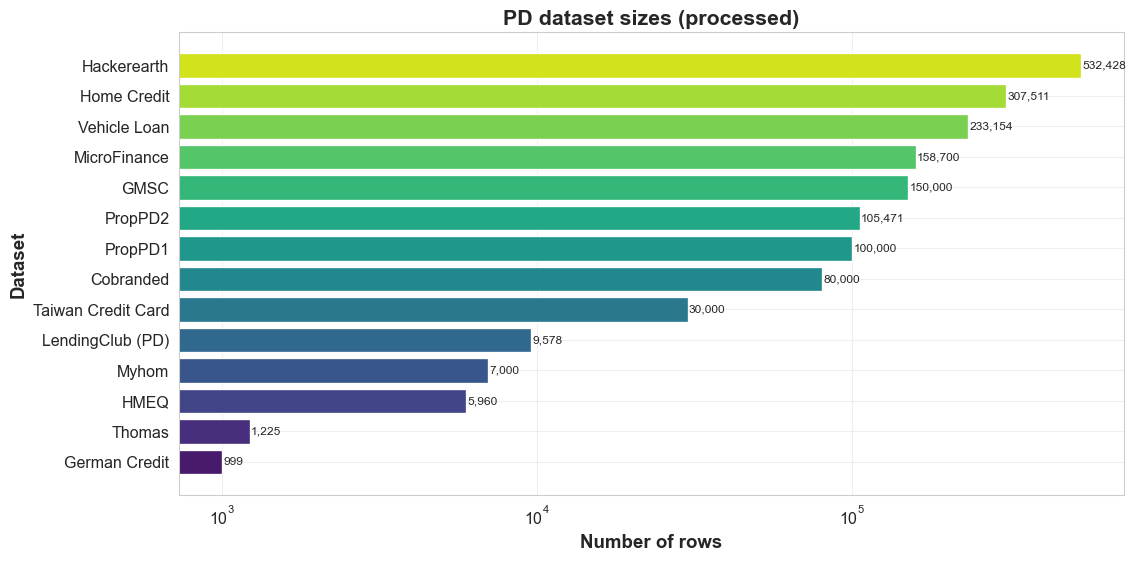

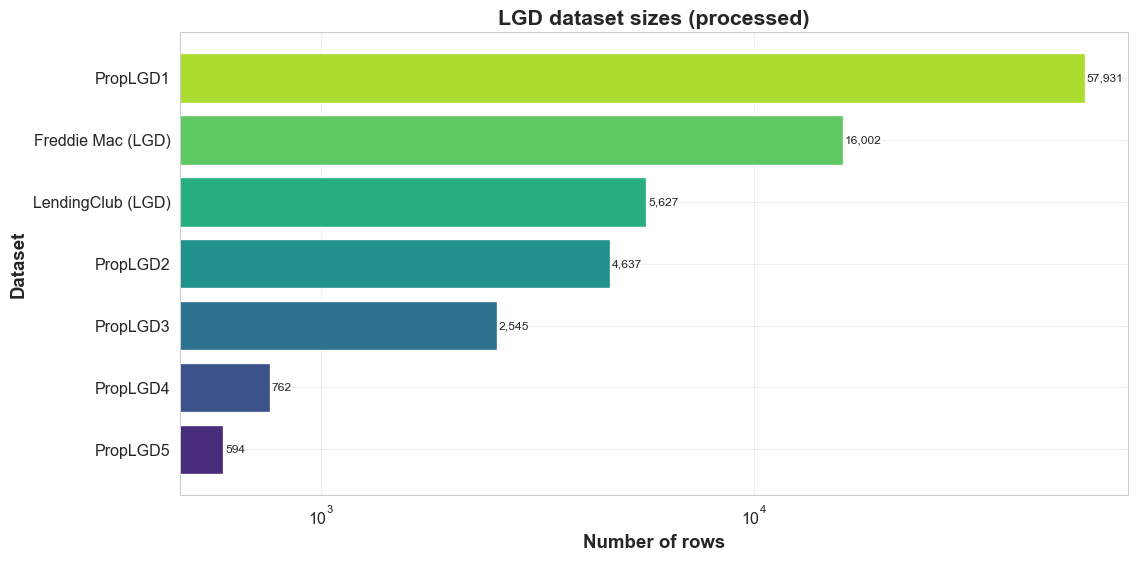

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/lgd_dataset_sizes.pdf')

In [2]:
dx.plot_dataset_size_bar('pd',  out_path=FIGURES_DIR / 'pd_dataset_sizes.pdf')
dx.plot_dataset_size_bar('lgd', out_path=FIGURES_DIR / 'lgd_dataset_sizes.pdf')


## Slide overview

One 16:9 figure for slide use: processed rows, processed feature counts, and PD class imbalance.


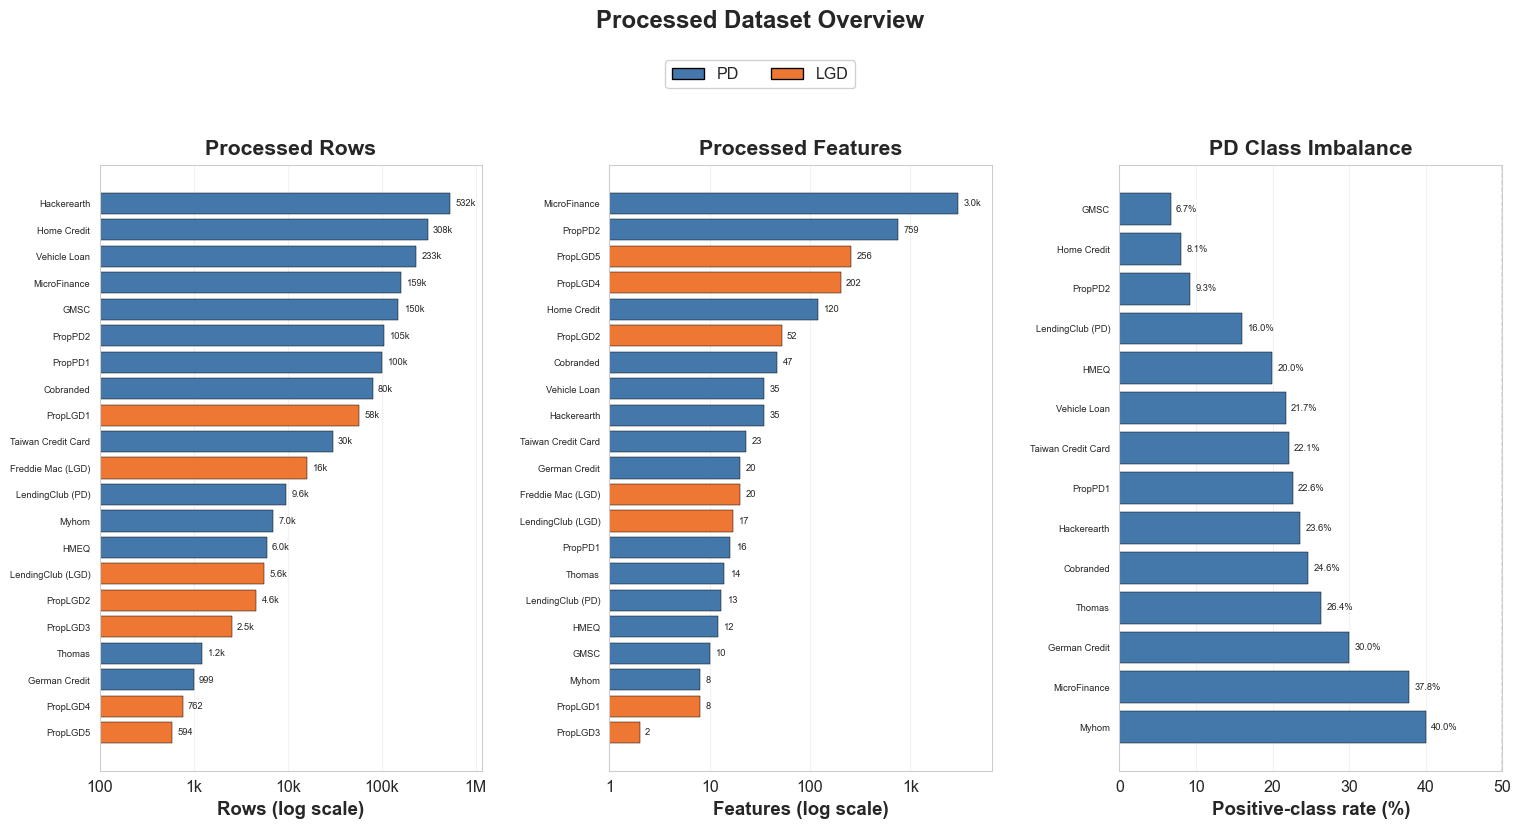

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/processed_dataset_overview_slide.pdf')

In [3]:
dx.plot_processed_dataset_overview_slide(
    out_path=FIGURES_DIR / 'processed_dataset_overview_slide.pdf'
)


## Targets — PD class balance, LGD loss distributions

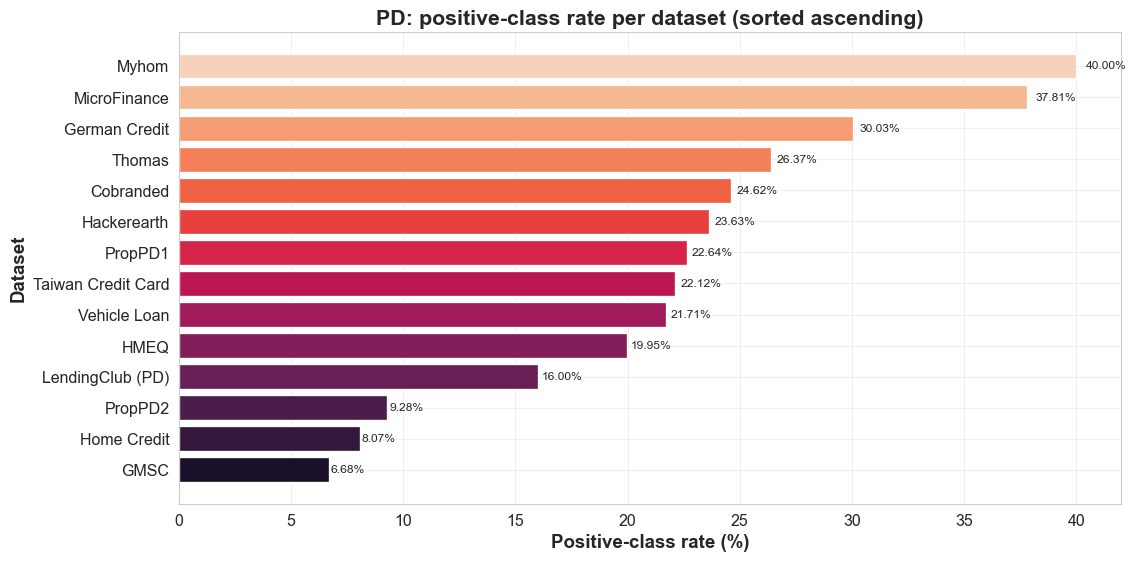

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/pd_target_balance.pdf')

In [4]:
dx.plot_target_balance(out_path=FIGURES_DIR / 'pd_target_balance.pdf')


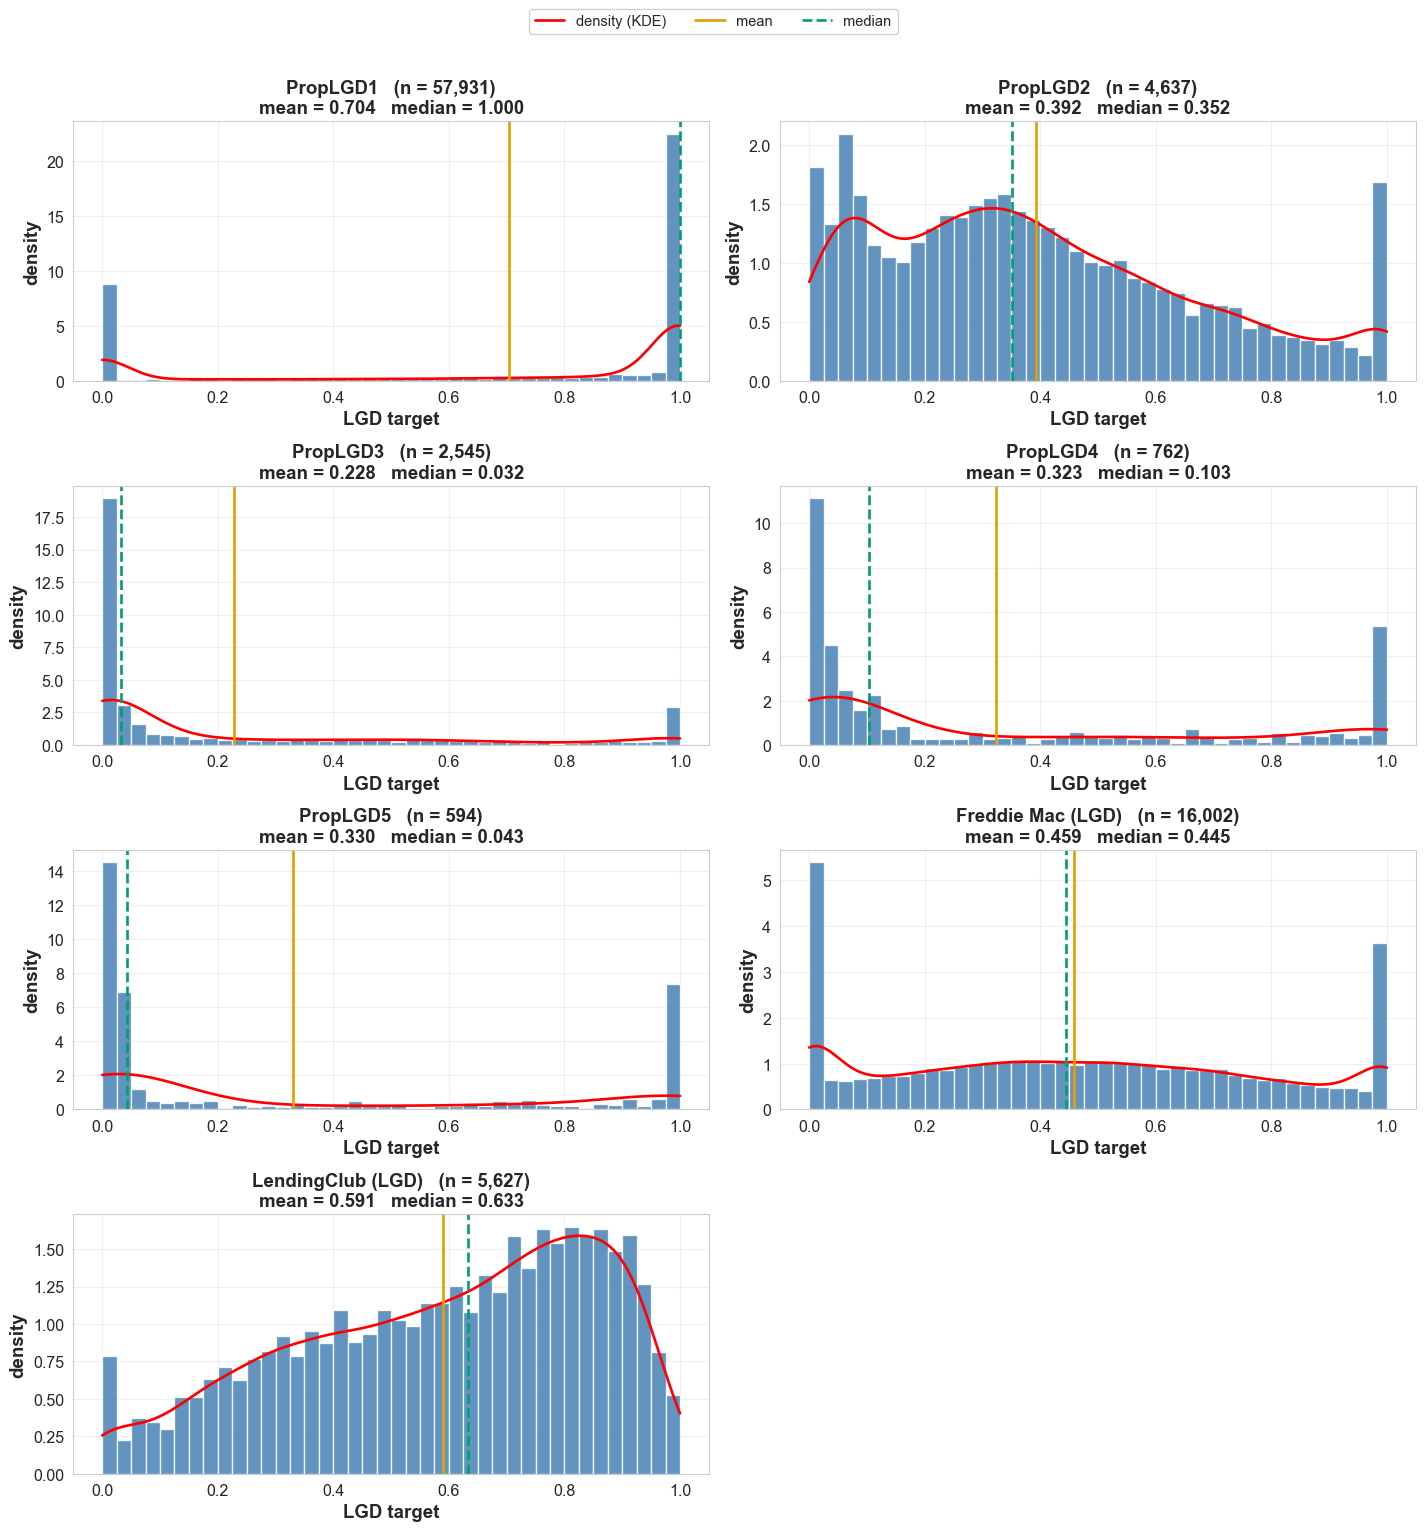

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/lgd_target_hists.pdf')

In [5]:
dx.plot_lgd_target_hists(out_path=FIGURES_DIR / 'lgd_target_hists.pdf')


## Per-dataset structure (edit the dataset names to inspect others)

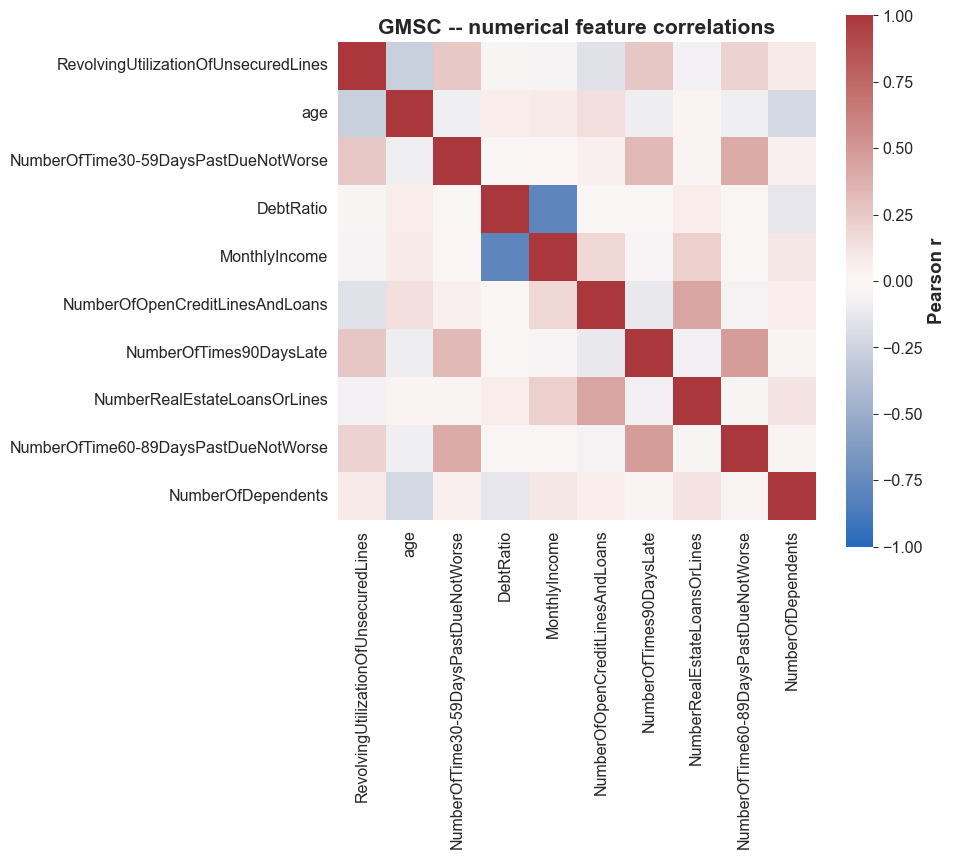

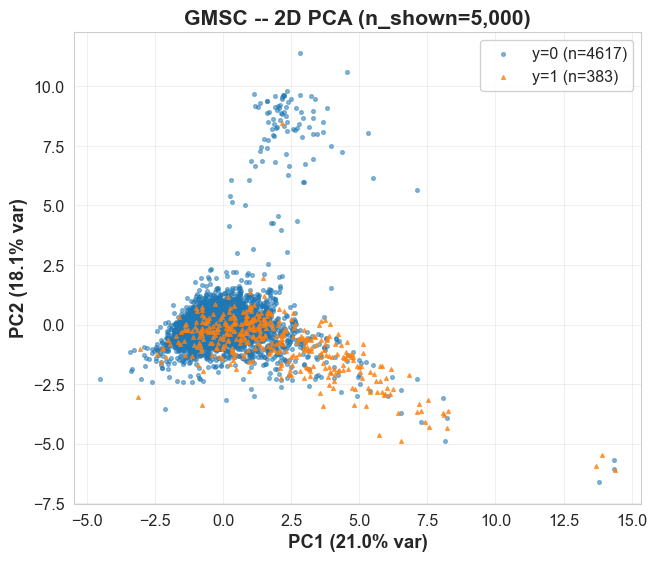

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/pca_gmsc.pdf')

In [6]:
dx.plot_correlation_heatmap('pd', '0001.gmsc', out_path=FIGURES_DIR / 'corr_gmsc.pdf')
dx.plot_pca_2d('pd', '0001.gmsc', out_path=FIGURES_DIR / 'pca_gmsc.pdf')


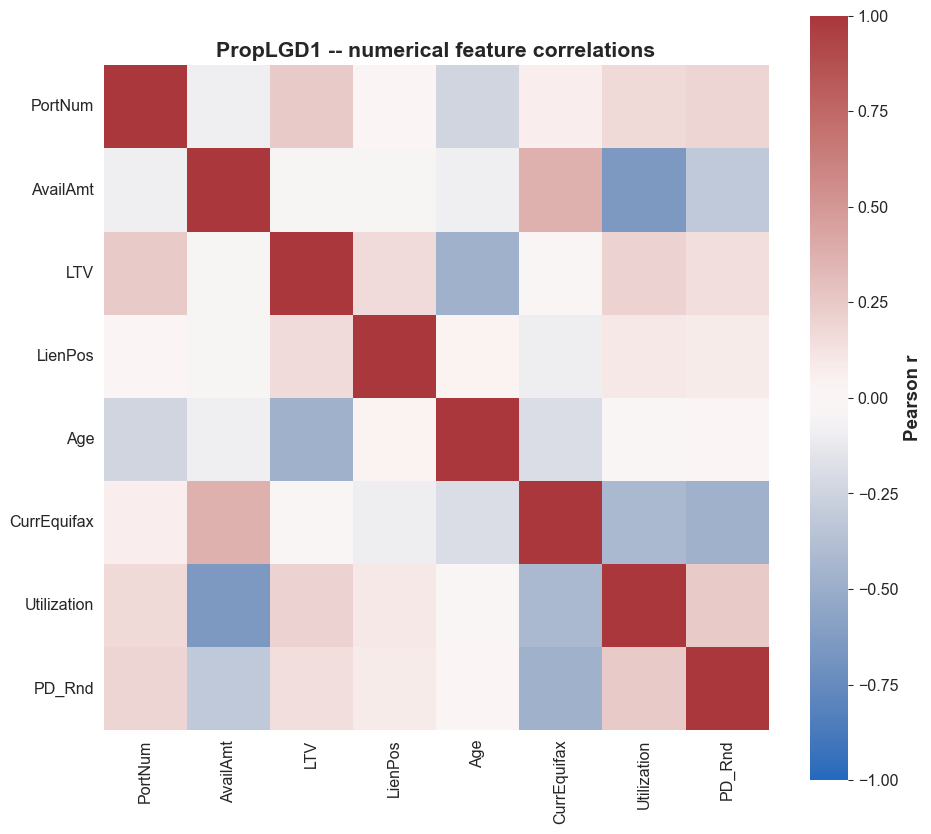

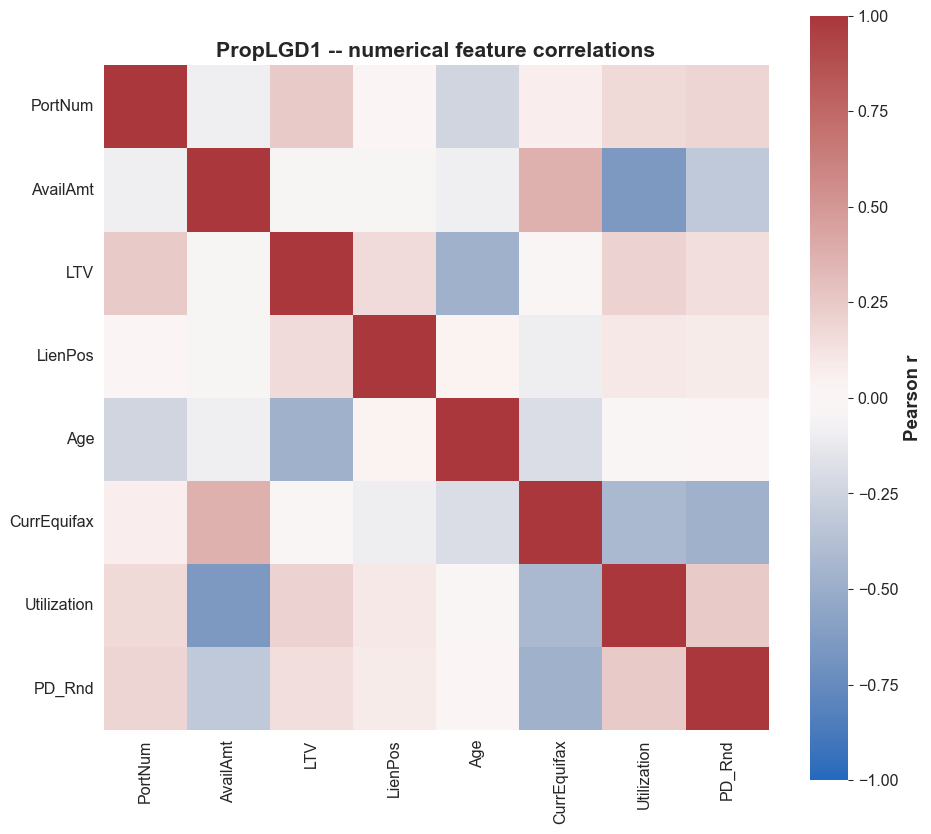

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/data_exploration/corr_proplgd1.pdf')

In [7]:
# PropLGD1 is proprietary, so this cell selects it by its ANONYMISED paper id
# and never names the real dataset -- the slug would otherwise be published in
# this tracked notebook, which is exactly what gitignoring dataset_registry.py
# is meant to prevent. The figure TITLE is anonymised automatically via the same
# registry. Two files are written: a neutral-named copy for the paper, and the
# slug-named one so older \includegraphics paths keep resolving. figures/ is
# gitignored, so neither is published.
from src.data.dataset_names import canonical_slug, display_name as ds_name
_lgd_corr_ds = canonical_slug('LGD3')          # -> PropLGD1
_lgd_corr_stem = _lgd_corr_ds.split('.', 1)[1]
dx.plot_correlation_heatmap('lgd', _lgd_corr_ds,
                            out_path=FIGURES_DIR / f'corr_{_lgd_corr_stem}.pdf')
dx.plot_correlation_heatmap('lgd', _lgd_corr_ds,
                            out_path=FIGURES_DIR / f'corr_{ds_name(_lgd_corr_ds).lower()}.pdf')


In [8]:
for title, table in [
    ('PD datasets', dx.paper_table(dx.processed_dataset_summary_table('pd'))),
    ('LGD datasets', dx.paper_table(dx.processed_dataset_summary_table('lgd'))),
    ('PD class balance', dx.paper_table(dx.pd_target_balance_table())),
    ('LGD target distribution', dx.paper_table(dx.lgd_target_distribution_table())),
]:
    preview(table, label=f'{title} ({len(table)} rows)')


**PD datasets (14 rows)**

,dataset,paper_id,task,rows,n_num_features,n_cat_features,n_total_features,target_mean,target_min,target_max
0,Cobranded,PD1,pd,80000,47,0,47,0.246213,0.0,1.0
1,German Credit,PD2,pd,999,7,13,20,0.300300,0.0,1.0
2,GMSC,PD3,pd,150000,10,0,10,0.066840,0.0,1.0
3,Hackerearth,PD4,pd,532428,27,8,35,0.236327,0.0,1.0
4,HMEQ,PD5,pd,5960,10,2,12,0.199497,0.0,1.0
5,Home Credit,PD6,pd,307511,104,16,120,0.080729,0.0,1.0
6,LendingClub (PD),PD7,pd,9578,12,1,13,0.160054,0.0,1.0
7,MicroFinance,PD8,pd,158700,2986,0,2986,0.378091,0.0,1.0
8,Myhom,PD9,pd,7000,7,1,8,0.400000,0.0,1.0
9,Taiwan Credit Card,PD10,pd,30000,23,0,23,0.221200,0.0,1.0


**LGD datasets (7 rows)**

,dataset,paper_id,task,rows,n_num_features,n_cat_features,n_total_features,target_mean,target_min,target_max
0,Freddie Mac (LGD),LGD1,lgd,16002,12,8,20,0.458843,0.00000,1.00000
1,LendingClub (LGD),LGD2,lgd,5627,10,7,17,0.590511,0.00000,1.00000
2,PropLGD1,LGD3,lgd,57931,8,0,8,0.704432,0.00000,1.00000
3,PropLGD2,LGD4,lgd,4637,29,23,52,0.392032,0.00000,1.00000
4,PropLGD3,LGD5,lgd,2545,2,0,2,0.228130,0.00001,0.99999
5,PropLGD4,LGD6,lgd,762,114,88,202,0.323387,0.00000,1.00000
6,PropLGD5,LGD7,lgd,594,179,77,256,0.330075,0.00000,1.00000


**PD class balance (14 rows)**

,dataset,paper_id,n_total,n_positive,n_negative,positive_rate,imbalance_ratio
0,GMSC,PD3,150000,10026,139974,0.06684,13.96
11,Home Credit,PD6,307511,24825,282686,0.08073,11.39
10,PropPD2,PD14,105471,9783,95688,0.09276,9.78
3,LendingClub (PD),PD7,9578,1533,8045,0.16005,5.25
12,HMEQ,PD5,5960,1189,4771,0.19950,4.01
2,Vehicle Loan,PD12,233154,50611,182543,0.21707,3.61
1,Taiwan Credit Card,PD10,30000,6636,23364,0.22120,3.52
8,PropPD1,PD13,100000,22639,77361,0.22639,3.42
5,Hackerearth,PD4,532428,125827,406601,0.23633,3.23
6,Cobranded,PD1,80000,19697,60303,0.24621,3.06


**LGD target distribution (7 rows)**

,dataset,paper_id,n,mean,std,median,skew,q05,q95,pct_zeros,pct_ones
0,Freddie Mac (LGD),LGD1,16002,0.4588,0.3182,0.4450,0.1487,0.0000,1.0000,11.42,8.07
1,LendingClub (LGD),LGD2,5627,0.5905,0.2579,0.6334,-0.4642,0.1233,0.9335,1.48,0.32
2,PropLGD1,LGD3,57931,0.7044,0.4170,1.0000,-0.9302,0.0000,1.0000,21.78,51.27
3,PropLGD2,LGD4,4637,0.3920,0.2714,0.3515,0.5556,0.0326,0.9420,3.62,3.71
4,PropLGD3,LGD5,2545,0.2281,0.3290,0.0321,1.3089,0.0000,1.0000,0.00,0.00
5,PropLGD4,LGD6,762,0.3234,0.3774,0.1032,0.8270,0.0000,1.0000,10.50,11.94
6,PropLGD5,LGD7,594,0.3301,0.4094,0.0435,0.7643,0.0000,1.0000,11.62,15.99


## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [9]:
notebook_report(
    'Data exploration',
    notebook='Data_Exploration.ipynb',
    about=('Inventory of the processed PD and LGD datasets: size, feature counts, '
           'target level, PD class balance and LGD target shape. Dataset names are '
           'the paper display names (proprietary sets anonymised).'),
    sections=[
        section('PD datasets (rows, features, target)',
                dx.paper_table(dx.processed_dataset_summary_table('pd'))),
        section('LGD datasets (rows, features, target)',
                dx.paper_table(dx.processed_dataset_summary_table('lgd'))),
        section('PD class balance', dx.paper_table(dx.pd_target_balance_table())),
        section('LGD target distribution',
                dx.paper_table(dx.lgd_target_distribution_table())),
    ],
)

DATA EXPLORATION -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Data_Exploration.ipynb
Contents        : Inventory of the processed PD and LGD datasets: size, feature counts, target level, PD class balance and LGD target shape. Dataset names are the paper display names (proprietary sets anonymised).
Sections        : 4

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] PD datasets (rows, features, target)
------------------------------------------------------------------------------
               dataset paper_id task    rows  n_num_features  n_cat_features  n_total_features  target_mean  target_min  target_max
0            Cobranded      PD1   pd   80000              47               0                47     0.246213         0.0         1.0
1        German Credit  

"==============================================================================\nDATA EXPLORATION -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Data_Exploration.ipynb\nContents        : Inventory of the processed PD and LGD datasets: size, feature counts, target level, PD class balance and LGD target shape. Dataset names are the paper display names (proprietary sets anonymised).\nSections        : 4\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] PD datasets (rows, features, target)\n------------------------------------------------------------------------------\n               dataset paper_id task    rows  n_num_features  n_cat_features  n_total_features  target_mean  target